# Module 1/2 exploration — SPY vol surface

## Environment sanity check
Confirm all required packages import cleanly and a live SPY price fetch works before relying on anything else.

In [5]:
import numpy as np
import pandas as pd
import scipy
import yfinance as yf
import arch
import matplotlib.pyplot as plt
import plotly

import sys
sys.path.append('..')

# Quick test — fetch SPY price
spy = yf.Ticker("SPY")
hist = spy.history(period="5d")
print(hist[['Close']].tail())
print("\nAll packages imported successfully")
print(f"SPY latest close: ${hist['Close'].iloc[-1]:.2f}")

                                Close
Date                                 
2026-06-10 00:00:00-04:00  725.429993
2026-06-11 00:00:00-04:00  737.760010
2026-06-12 00:00:00-04:00  741.750000
2026-06-16 00:00:00-04:00  752.820007

All packages imported successfully
SPY latest close: $752.82


## Spot price & risk-free rate
Fetch SPY spot and the risk-free rate (^IRX) via `src.data` — these are shared inputs, fetched once, passed down to everything below.

In [6]:
import logging
logging.basicConfig(level=logging.INFO)


from src.data import fetch_spot_price, fetch_risk_free_rate

spot = fetch_spot_price()
rate = fetch_risk_free_rate()

print(f"SPY spot: {spot:.2f}")
print(f"Risk-free rate: {rate:.4%}")

INFO:src.data:Fetched spot price for SPY: 752.92
INFO:src.data:Fetched risk-free rate from ^IRX: 3.6350%


SPY spot: 752.92
Risk-free rate: 3.6350%


## Options chain fetch
Pull SPY's nearest-expiry chain through `fetch_options_chain` and sanity-check the bid/volume/OI/moneyness filtering — see how many rows survive.

In [7]:
from src.data import fetch_options_chain, fetch_spot_price

spot = fetch_spot_price()
expiries = yf.Ticker("SPY").options
print(expiries[:5])  # see what's available

chain = fetch_options_chain("SPY", expiries[0], spot_price=spot)
print(chain.head())
print(f"\n{len(chain)} cleaned rows")

INFO:src.data:Fetched spot price for SPY: 752.92


('2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23')


INFO:src.data:Cleaned options chain for SPY 2026-06-16: kept 132/269 rows


   strike option_type  mid_price     bid     ask  volume  open_interest  \
0   610.0        call    143.285  141.90  144.67     1.0            1.0   
1   625.0        call    128.300  126.92  129.68    31.0           31.0   
2   635.0        call    118.455  117.17  119.74     2.0            3.0   
3   650.0        call    103.260  101.85  104.67     2.0            2.0   
4   655.0        call     98.215   96.86   99.57     5.0            9.0   

       expiry    T  
0  2026-06-16  0.0  
1  2026-06-16  0.0  
2  2026-06-16  0.0  
3  2026-06-16  0.0  
4  2026-06-16  0.0  

132 cleaned rows


## Vol surface construction
Build the IV surface across a handful of expiries (skipping the ~0DTE ones, where T≈0 breaks the BS solve) via `compute_surface`. Check solve coverage (skipped count) and that the implied_vol distribution looks sane.

In [8]:
from src.vol_surface import compute_surface
import yfinance as yf

all_expiries = yf.Ticker("SPY").options
# pick a handful spanning different horizons — skip the very nearest (T≈0) ones for now
expiries = all_expiries[3:8]
print(expiries)

surface = compute_surface("SPY", expiries)
print(surface.head())
print(surface["implied_vol"].describe())

('2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26')


INFO:src.data:Fetched spot price for SPY: 752.92
INFO:src.data:Fetched risk-free rate from ^IRX: 3.6350%
INFO:src.data:Cleaned options chain for SPY 2026-06-22: kept 188/229 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-23: kept 166/216 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-24: kept 147/185 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-25: kept 122/141 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-26: kept 278/299 rows


Surface built: 609 options, 0 skipped (no IV solution)
   strike option_type      expiry         T  mid_price  implied_vol
0   753.0        call  2026-06-22  0.016438      4.085     0.101225
1   754.0        call  2026-06-22  0.016438      3.505     0.098931
2   755.0        call  2026-06-22  0.016438      3.080     0.099595
3   756.0        call  2026-06-22  0.016438      2.680     0.099859
4   757.0        call  2026-06-22  0.016438      2.230     0.097644
count    609.000000
mean       0.225594
std        0.148309
min        0.095798
25%        0.126285
50%        0.177942
75%        0.249362
max        0.867484
Name: implied_vol, dtype: float64


### Smile check — nearest expiry in the surface
Plot strike vs. IV for the first expiry actually included above (`expiries[0]`, not a hardcoded date — a stale literal here silently produced an empty plot once already).

In [ ]:
import matplotlib.pyplot as plt

near_expiry = surface[surface["expiry"] == expiries[0]].sort_values("strike")
plt.plot(near_expiry["strike"], near_expiry["implied_vol"], marker='o')
plt.xlabel("Strike")
plt.ylabel("Implied Vol")
plt.title(f"SPY Vol Smile — {expiries[0]}")
plt.show()

### Smile check — ~30 days out
Independently pick the expiry closest to 30 calendar days from today and rebuild a single-expiry surface for it.

INFO:src.data:Fetched spot price for SPY: 752.92
INFO:src.data:Fetched risk-free rate from ^IRX: 3.6350%


Today: 2026-06-16, target ~30d: 2026-07-16, closest expiry: 2026-07-17


INFO:src.data:Cleaned options chain for SPY 2026-07-17: kept 393/431 rows


Surface built: 244 options, 0 skipped (no IV solution)


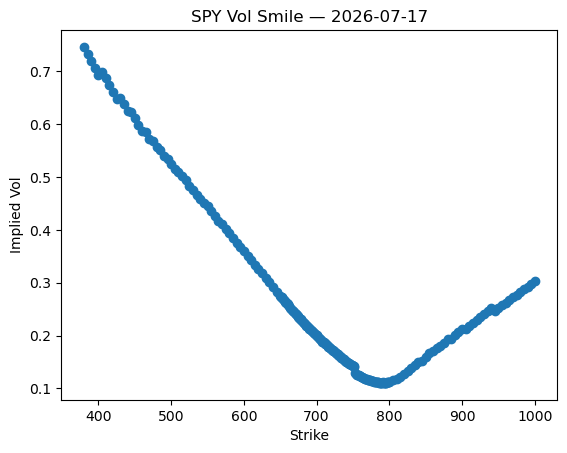

count    244.000000
mean       0.253379
std        0.156568
min        0.110343
25%        0.145224
50%        0.204532
75%        0.273826
max        0.746338
Name: implied_vol, dtype: float64


In [10]:
import datetime

today = datetime.date.today()
target = today + datetime.timedelta(days=30)

# find the expiry closest to 30 days out
closest_expiry = min(all_expiries, key=lambda e: abs((datetime.date.fromisoformat(e) - target).days))
print(f"Today: {today}, target ~30d: {target}, closest expiry: {closest_expiry}")

surface_30d = compute_surface("SPY", [closest_expiry])

plt.plot(
    surface_30d.sort_values("strike")["strike"],
    surface_30d.sort_values("strike")["implied_vol"],
    marker='o'
)
plt.xlabel("Strike")
plt.ylabel("Implied Vol")
plt.title(f"SPY Vol Smile — {closest_expiry}")
plt.show()

print(surface_30d["implied_vol"].describe())

### Cross-check against VIX
Compare ATM IV (two nearest strikes) to spot VIX. Note: not strictly apples-to-apples — VIX is a model-free variance-swap rate over a wide OTM strip across two expiries, not a single-expiry ATM BS-IV, so a few points of gap is expected, not a bug.

In [11]:
vix = fetch_spot_price("^VIX")
print(f"VIX: {vix:.2f}")

# find the strike(s) closest to spot — that's your ATM IV
atm_rows = surface_30d.iloc[(surface_30d["strike"] - spot).abs().argsort()[:2]]
print(atm_rows[["strike", "option_type", "implied_vol"]])

INFO:src.data:Fetched spot price for ^VIX: 15.86


VIX: 15.86
     strike option_type  implied_vol
0     753.0        call     0.128761
243   752.0         put     0.141184


### Full surface + plotting functions
Rebuild over a wider expiry range and exercise `plot_vol_smile`, `plot_term_structure`, `plot_vol_surface` end to end — this is Module 2's actual deliverable, validated here.

INFO:src.data:Fetched spot price for SPY: 752.92
INFO:src.data:Fetched risk-free rate from ^IRX: 3.6350%
INFO:src.data:Cleaned options chain for SPY 2026-06-22: kept 188/229 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-23: kept 166/216 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-24: kept 147/185 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-25: kept 122/141 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-26: kept 278/299 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-30: kept 583/614 rows
INFO:src.data:Cleaned options chain for SPY 2026-07-02: kept 286/322 rows


Surface built: 1134 options, 0 skipped (no IV solution)


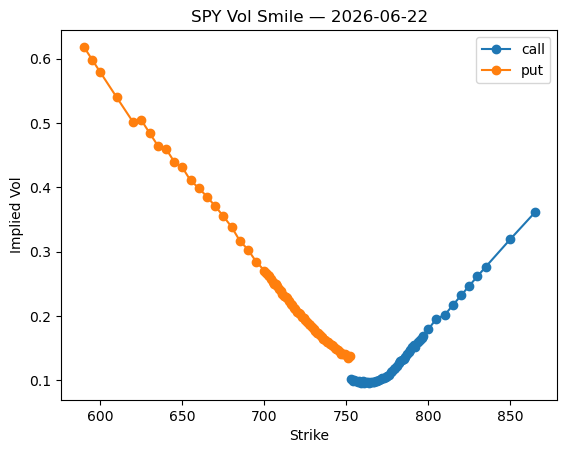

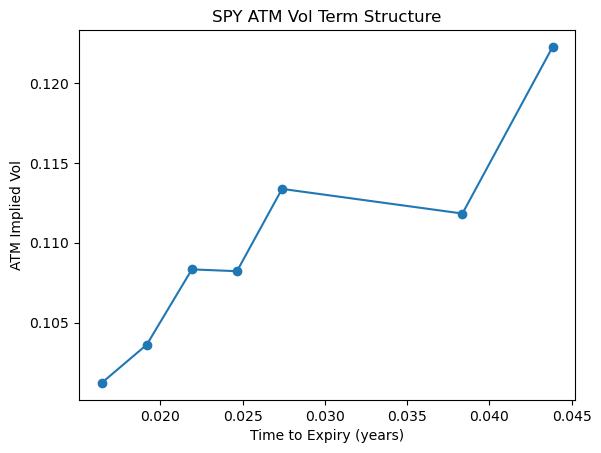

In [12]:
from src.vol_surface import plot_vol_smile, plot_term_structure, plot_vol_surface

expiries_for_surface = all_expiries[3:10]
full_surface = compute_surface("SPY", expiries_for_surface)

plot_vol_smile(full_surface, expiries_for_surface[0])
plot_term_structure(full_surface, spot)
plot_vol_surface(full_surface)

## Module 3 — realised vol / GARCH test suite
Run `tests/test_realised_vol.py` in-notebook as a quick green/red check before moving on to `src/analysis.py` (IV vs. realised vol decomposition — pending).

In [15]:
import subprocess
result = subprocess.run(
    ["pytest", "tests/test_realised_vol.py", "-v"],
    capture_output=True,
    text=True,
    cwd=".."  # adjust if notebook is in notebooks/ subdirectory
)
print(result.stdout)
print(result.stderr)

============================= test session starts ==============================
platform darwin -- Python 3.12.4, pytest-7.4.4, pluggy-1.0.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
rootdir: /Users/bilallittle/vol-surface-project
plugins: anyio-4.2.0
collecting ... collected 37 items

tests/test_realised_vol.py::TestComputeLogReturns::test_output_length PASSED [  2%]
tests/test_realised_vol.py::TestComputeLogReturns::test_output_index_aligned PASSED [  5%]
tests/test_realised_vol.py::TestComputeLogReturns::test_known_value PASSED [  8%]
tests/test_realised_vol.py::TestComputeLogReturns::test_output_is_series PASSED [ 10%]
tests/test_realised_vol.py::TestComputeLogReturns::test_no_nans_in_output PASSED [ 13%]
tests/test_realised_vol.py::TestComputeLogReturns::test_raises_on_non_series PASSED [ 16%]
tests/test_realised_vol.py::TestComputeLogReturns::test_raises_on_single_observation PASSED [ 18%]
tests/test_realised_vol.py::TestComputeLogReturns::test_raises_on_nan_in_prices